# Objective 5: Regression - Pre-Race Exact Finishing Position Prediction
🎯 Objective 5 = Modèle prédictif réel (pré-race)
**Goal:** Predict the exact finishing position of each driver before the race starts (using only pre-race data).

This objective is similar to Objective 3 but strictly focuses on features available **before** the race (e.g., qualifying, grid, season standing) to ensure predictive utility.

**Models Tested:**
- Simple Linear Regression
- Multiple Linear Regression
- KNN Regressor
- Support Vector Regression (SVR)
- Decision Tree Regressor
- Random Forest Regressor

In [21]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid")

print("✅ Imports chargés")

✅ Imports chargés


## 1. Data Preparation

In [22]:
print("="*60)
print("CHARGEMENT DES DONNÉES")
print("="*60)

df = pd.read_csv('prepared_data.csv')
print(f"Shape initiale: {df.shape}")

# Trier par année puis round
df = df.sort_values(['year', 'round']).reset_index(drop=True)

print(f"Shape après tri: {df.shape}")
print(f"Années: {df['year'].min()} - {df['year'].max()}")

CHARGEMENT DES DONNÉES
Shape initiale: (26487, 16)
Shape après tri: (26487, 16)
Années: 1950 - 2024


In [ ]:
#PRÉTRAITEMENT (imputation + scaling + One-Hot)

CRÉATION DE LA CIBLE
Statistiques de la cible:
Moyenne: -0.84
Médiane: 0.00
Écart-type: 8.19
Min: -20.00
Max: 30.00


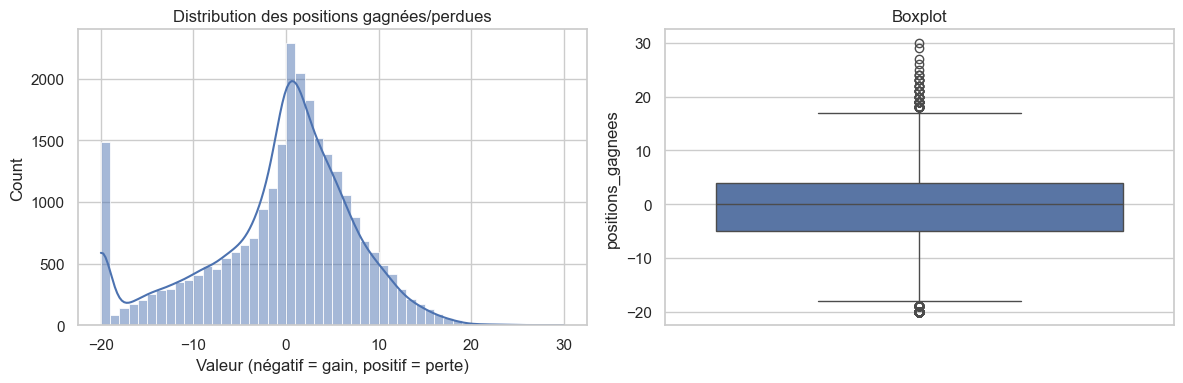

In [23]:
print("="*60)
print("CRÉATION DE LA CIBLE")
print("="*60)

# Cible = positions gagnées/perdues (négatif = gain, positif = perte)
df['positions_gagnees'] = df['grid'] - df['finish_pos_penalty']

print(f"Statistiques de la cible:")
print(f"Moyenne: {df['positions_gagnees'].mean():.2f}")
print(f"Médiane: {df['positions_gagnees'].median():.2f}")
print(f"Écart-type: {df['positions_gagnees'].std():.2f}")
print(f"Min: {df['positions_gagnees'].min():.2f}")
print(f"Max: {df['positions_gagnees'].max():.2f}")

# Visualisation
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(df['positions_gagnees'], bins=50, kde=True)
plt.title("Distribution des positions gagnées/perdues")
plt.xlabel("Valeur (négatif = gain, positif = perte)")

plt.subplot(1, 2, 2)
sns.boxplot(y=df['positions_gagnees'])
plt.title("Boxplot")

plt.tight_layout()
plt.show()

In [25]:
print("="*60)
print("CRÉATION DES FEATURES")
print("="*60)

# Features de base
BASE_FEATURES = [
    'grid',
    'driver_standing_pos',
    'driver_points_cum',
    'driver_wins_cum',
    'constructor_standing_pos',
    'constructor_points_cum',
    'constructor_wins_cum',
    'country_encoded'
]

# Features de forme récente (rolling means)
df['avg_pos_gagnees_3'] = df['positions_gagnees'].rolling(3, min_periods=1).mean()
df['avg_grid_3'] = df['grid'].rolling(3, min_periods=1).mean()
df['grid_driver_interaction'] = df['grid'] * df['driver_standing_pos']

# Features finales
FEATURES_FINALES = BASE_FEATURES + [
    'avg_pos_gagnees_3', 
    'avg_grid_3', 
    'grid_driver_interaction'
]

print(f"Nombre de features: {len(FEATURES_FINALES)}")
for f in FEATURES_FINALES:
    print(f"  - {f}")

X = df[FEATURES_FINALES]
y = df['positions_gagnees']

print(f"\nShape X: {X.shape}, Shape y: {y.shape}")

CRÉATION DES FEATURES
Nombre de features: 11
  - grid
  - driver_standing_pos
  - driver_points_cum
  - driver_wins_cum
  - constructor_standing_pos
  - constructor_points_cum
  - constructor_wins_cum
  - country_encoded
  - avg_pos_gagnees_3
  - avg_grid_3
  - grid_driver_interaction

Shape X: (26487, 11), Shape y: (26487,)


In [26]:
print("="*60)
print("SPLIT TEMPOREL")
print("="*60)

split_idx = int(len(df) * 0.8)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]
y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")
print(f"Train années: {df['year'].iloc[:split_idx].min()} - {df['year'].iloc[:split_idx].max()}")
print(f"Test années: {df['year'].iloc[split_idx:].min()} - {df['year'].iloc[split_idx:].max()}")

SPLIT TEMPOREL
Train shape: (21189, 11)
Test shape: (5298, 11)
Train années: 1950 - 2011
Test années: 2011 - 2024


## 2. Modeling & Evaluation

In [27]:
print("="*60)
print("PRÉTRAITEMENT")
print("="*60)

# Identifier les colonnes
num_cols = X_train.select_dtypes(include=["number", "bool"]).columns.tolist()
cat_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
print(f"Colonnes numériques: {len(num_cols)}")
print(f"Colonnes catégorielles: {len(cat_cols)}")

# Transformateurs
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", ohe),
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols),
    ],
    remainder="drop"
)

# Validation croisée temporelle
tscv = TimeSeriesSplit(n_splits=3)
print(f"TimeSeriesSplit: {tscv.n_splits} folds")

# Fonction de métriques
def regression_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    try:
        rmse = mean_squared_error(y_true, y_pred, squared=False)
    except TypeError:
        rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    r2 = r2_score(y_true, y_pred)
    return {"MAE": float(mae), "RMSE": float(rmse), "R2": float(r2)}

def plot_diagnostics(y_true, y_pred, title_prefix=""):
    residuals = y_true - y_pred
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    axes[0].scatter(y_true, y_pred, alpha=0.35)
    min_val = min(np.min(y_true), np.min(y_pred))
    max_val = max(np.max(y_true), np.max(y_pred))
    axes[0].plot([min_val, max_val], [min_val, max_val], "r--", linewidth=2)
    axes[0].set_title(f"{title_prefix}Prédiction vs Réel")
    axes[0].set_xlabel("Réel (positions gagnées)")
    axes[0].set_ylabel("Prédit")
    
    sns.histplot(residuals, bins=30, kde=True, ax=axes[1])
    axes[1].set_title(f"{title_prefix}Distribution des résidus")
    axes[1].set_xlabel("Résidu")
    
    plt.tight_layout()
    plt.show()

def make_pipeline(model):
    return Pipeline(steps=[("preprocess", preprocess), ("model", model)])

# Stockage des résultats
results = []

def add_result(model_name, model_obj, test_metrics):
    global results
    results = [r for r in results if r["modele"] != model_name]
    results.append({
        "modele": model_name,
        "test_mae": test_metrics["MAE"],
        "test_rmse": test_metrics["RMSE"],
        "test_r2": test_metrics["R2"],
    })

print("✅ Prétraitement prêt")

PRÉTRAITEMENT
Colonnes numériques: 11
Colonnes catégorielles: 0
TimeSeriesSplit: 3 folds
✅ Prétraitement prêt


In [ ]:
## 4. MODÈLES DE RÉGRESSION LINÉAIRE

RÉGRESSION LINÉAIRE
MAE: 1.2304
RMSE: 2.3638
R²: 0.8149


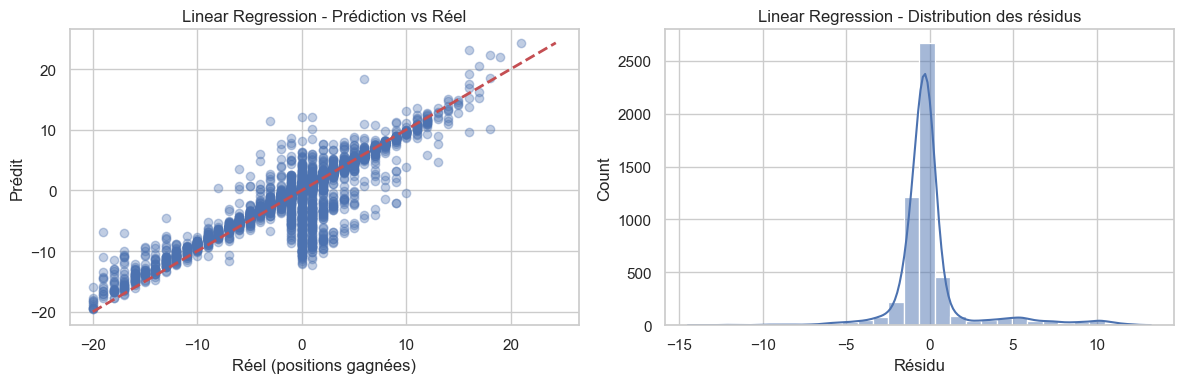

In [28]:
# =====================================================
# 4. MODÈLES DE RÉGRESSION LINÉAIRE (CORRIGÉS)
# =====================================================
print("="*60)
print("RÉGRESSION LINÉAIRE")
print("="*60)

lr = LinearRegression()
pipe_lr = make_pipeline(lr)
pipe_lr.fit(X_train, y_train)

y_pred_lr = pipe_lr.predict(X_test)
metrics_lr = regression_metrics(y_test, y_pred_lr)

print(f"MAE: {metrics_lr['MAE']:.4f}")
print(f"RMSE: {metrics_lr['RMSE']:.4f}")
print(f"R²: {metrics_lr['R2']:.4f}")

plot_diagnostics(y_test, y_pred_lr, "Linear Regression - ")
add_result("LinearRegression", pipe_lr, metrics_lr)

In [ ]:
# 4.2 Multiple Linear Regression (toutes les features pré-race)


RÉGRESSION LINÉAIRE MULTIPLE
MAE: 1.2304
RMSE: 2.3638
R²: 0.8149


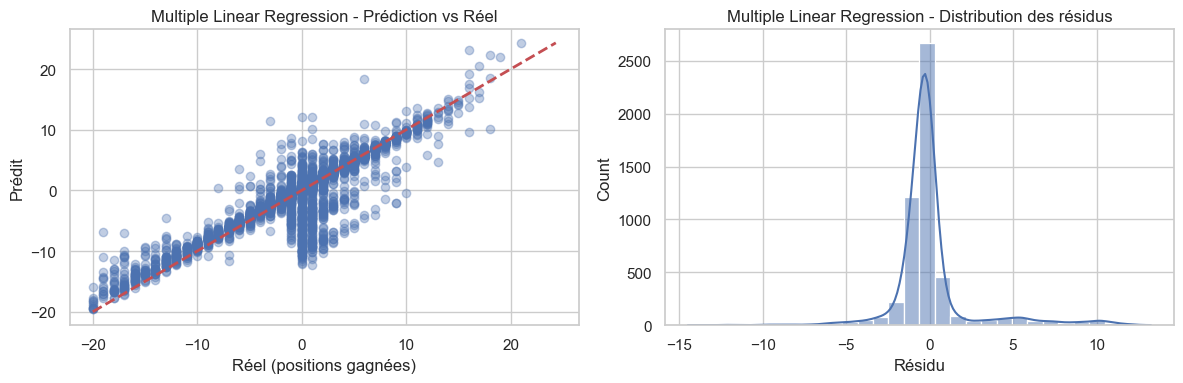

In [30]:
# 4.2 Multiple Linear Regression (toutes les features pré-race)
print("\n" + "="*60)
print("RÉGRESSION LINÉAIRE MULTIPLE")
print("="*60)

mlr_pipeline = make_pipeline(LinearRegression())
mlr_pipeline.fit(X_train, y_train)
y_pred_mlr = mlr_pipeline.predict(X_test)

metrics_mlr = regression_metrics(y_test, y_pred_mlr)
print(f"MAE: {metrics_mlr['MAE']:.4f}")
print(f"RMSE: {metrics_mlr['RMSE']:.4f}")
print(f"R²: {metrics_mlr['R2']:.4f}")

plot_diagnostics(y_test, y_pred_mlr, "Multiple Linear Regression - ")

# Version corrigée : suppression du paramètre "Linear"
add_result("MultipleLinear", mlr_pipeline, metrics_mlr)

In [ ]:
# 5. MODÈLES NON-LINÉAIRES (avec Grid Search / Random Search)

In [ ]:
# 5.1 KNN


KNN REGRESSOR
Meilleurs hyperparamètres:
{'model__n_neighbors': 7, 'model__p': 2, 'model__weights': 'distance'}
MAE: 1.9017
RMSE: 3.2044
R²: 0.6598


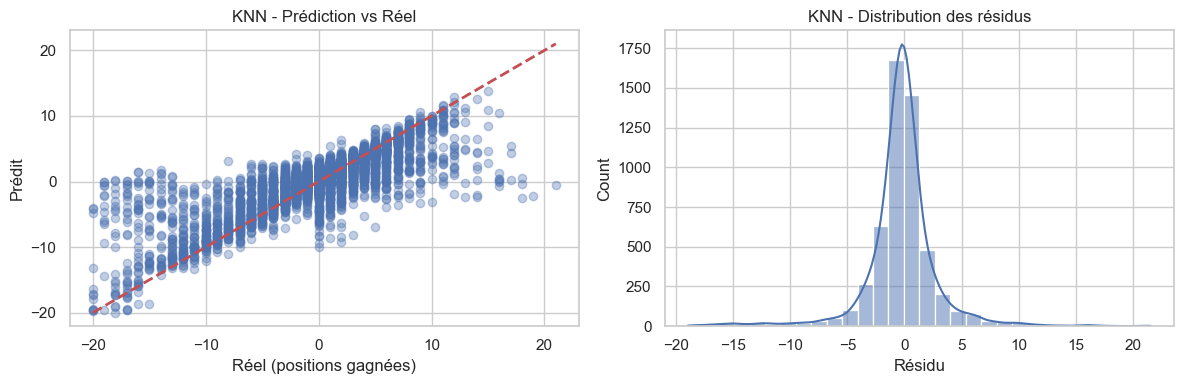

In [31]:
print("\n" + "="*60)
print("KNN REGRESSOR")
print("="*60)

from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor()
pipe_knn = make_pipeline(knn)

param_grid_knn = {
    "model__n_neighbors": [3, 5, 7, 9, 11, 15],
    "model__weights": ["uniform", "distance"],
    "model__p": [1, 2],
}

gs_knn = GridSearchCV(pipe_knn, param_grid_knn, cv=tscv, scoring="neg_mean_absolute_error", n_jobs=-1)
gs_knn.fit(X_train, y_train)

print("Meilleurs hyperparamètres:")
print(gs_knn.best_params_)

y_pred_knn = gs_knn.predict(X_test)
metrics_knn = regression_metrics(y_test, y_pred_knn)
print(f"MAE: {metrics_knn['MAE']:.4f}")
print(f"RMSE: {metrics_knn['RMSE']:.4f}")
print(f"R²: {metrics_knn['R2']:.4f}")

plot_diagnostics(y_test, y_pred_knn, "KNN - ")

# Version corrigée : suppression du paramètre "GridSearch"
add_result("KNN", gs_knn, metrics_knn)

In [ ]:
# 5.2 SVR


SUPPORT VECTOR REGRESSION (SVR)
Meilleurs hyperparamètres:
{'model__C': 10, 'model__epsilon': 0.05, 'model__gamma': 'scale', 'model__kernel': 'rbf'}
MAE: 0.9623
RMSE: 2.5405
R²: 0.7862


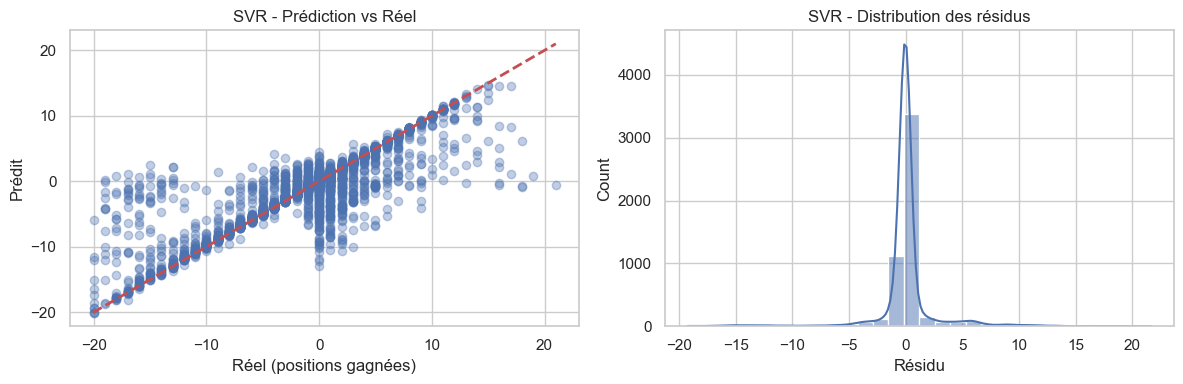

In [32]:
print("\n" + "="*60)
print("SUPPORT VECTOR REGRESSION (SVR)")
print("="*60)

from sklearn.svm import SVR

svr = SVR()
pipe_svr = make_pipeline(svr)

param_grid_svr = {
    "model__kernel": ["rbf", "linear"],
    "model__C": [0.1, 1, 10],
    "model__epsilon": [0.05, 0.2, 0.5],
    "model__gamma": ["scale", "auto"],
}

gs_svr = GridSearchCV(pipe_svr, param_grid_svr, cv=tscv, scoring="neg_mean_absolute_error", n_jobs=-1)
gs_svr.fit(X_train, y_train)

print("Meilleurs hyperparamètres:")
print(gs_svr.best_params_)

y_pred_svr = gs_svr.predict(X_test)
metrics_svr = regression_metrics(y_test, y_pred_svr)
print(f"MAE: {metrics_svr['MAE']:.4f}")
print(f"RMSE: {metrics_svr['RMSE']:.4f}")
print(f"R²: {metrics_svr['R2']:.4f}")

plot_diagnostics(y_test, y_pred_svr, "SVR - ")

# Version corrigée : suppression du paramètre "GridSearch"
add_result("SVR", gs_svr, metrics_svr)

In [ ]:
# 5.3 Decision Tree


DECISION TREE REGRESSOR
Meilleurs hyperparamètres:
{'model__max_depth': 12, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 8, 'model__min_samples_split': 10}
MAE: 2.2599
RMSE: 3.0799
R²: 0.6857


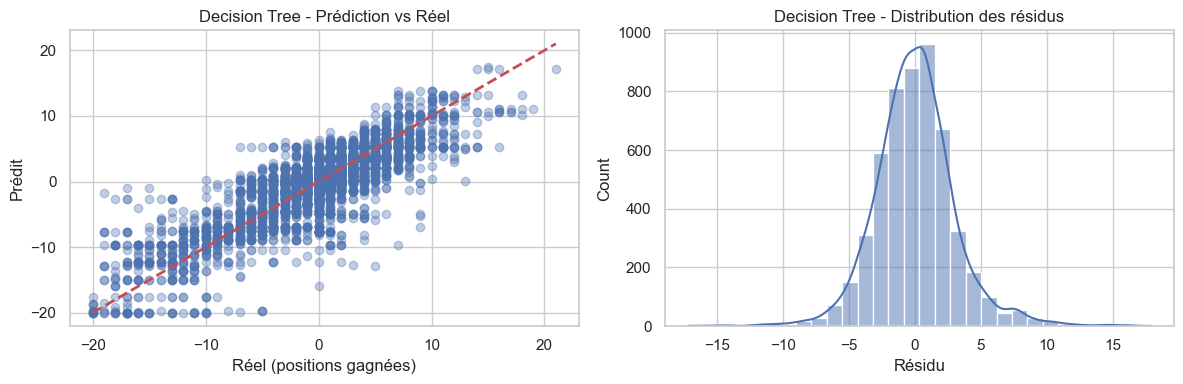

In [33]:
print("\n" + "="*60)
print("DECISION TREE REGRESSOR")
print("="*60)

from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=RANDOM_STATE)
pipe_dt = make_pipeline(dt)

param_grid_dt = {
    "model__max_depth": [5, 8, 10, 12],  # None peut causer du surapprentissage
    "model__min_samples_split": [10, 20, 30],
    "model__min_samples_leaf": [5, 8, 10],
    "model__max_features": ["sqrt", "log2"],
}

gs_dt = GridSearchCV(pipe_dt, param_grid_dt, cv=tscv, scoring="neg_mean_absolute_error", n_jobs=-1)
gs_dt.fit(X_train, y_train)

print("Meilleurs hyperparamètres:")
print(gs_dt.best_params_)

y_pred_dt = gs_dt.predict(X_test)
metrics_dt = regression_metrics(y_test, y_pred_dt)
print(f"MAE: {metrics_dt['MAE']:.4f}")
print(f"RMSE: {metrics_dt['RMSE']:.4f}")
print(f"R²: {metrics_dt['R2']:.4f}")

plot_diagnostics(y_test, y_pred_dt, "Decision Tree - ")

# Version corrigée : suppression du paramètre "GridSearch"
add_result("DecisionTree", gs_dt, metrics_dt)

In [ ]:
# 5.4 Random Forest


RANDOM FOREST REGRESSOR
Meilleurs hyperparamètres:
{'model__max_depth': 10, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 5, 'model__min_samples_split': 15, 'model__n_estimators': 150}
MAE: 1.4312
RMSE: 2.0354
R²: 0.8627


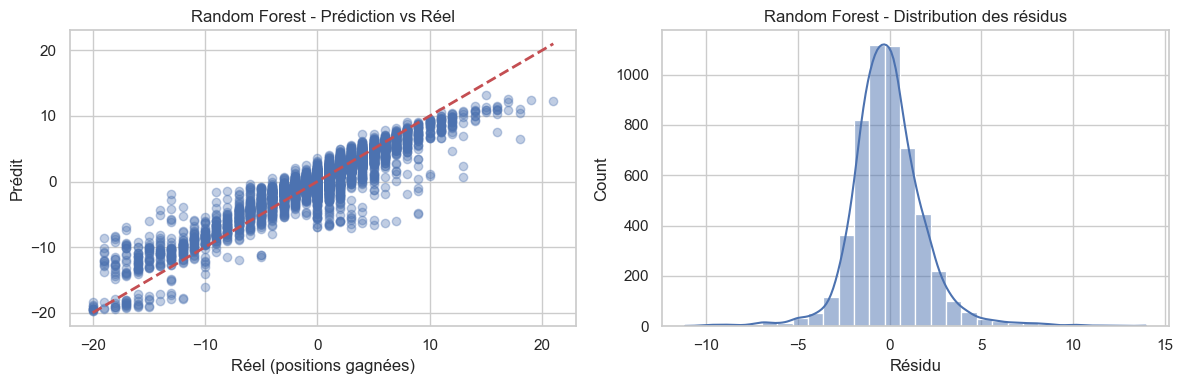

In [34]:
print("\n" + "="*60)
print("RANDOM FOREST REGRESSOR")
print("="*60)

from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)
pipe_rf = make_pipeline(rf)

# Grille réduite pour éviter le surapprentissage
param_grid_rf = {
    "model__n_estimators": [100, 150],
    "model__max_depth": [5, 7, 10],  # Supprimé None (surapprentissage)
    "model__min_samples_split": [15, 25],
    "model__min_samples_leaf": [5, 8],
    "model__max_features": ["sqrt", "log2"],
}

gs_rf = GridSearchCV(pipe_rf, param_grid_rf, cv=tscv, scoring="neg_mean_absolute_error", n_jobs=-1)
gs_rf.fit(X_train, y_train)

print("Meilleurs hyperparamètres:")
print(gs_rf.best_params_)

y_pred_rf = gs_rf.predict(X_test)
metrics_rf = regression_metrics(y_test, y_pred_rf)
print(f"MAE: {metrics_rf['MAE']:.4f}")
print(f"RMSE: {metrics_rf['RMSE']:.4f}")
print(f"R²: {metrics_rf['R2']:.4f}")

plot_diagnostics(y_test, y_pred_rf, "Random Forest - ")

# Version corrigée : suppression du paramètre "GridSearch"
add_result("RandomForest", gs_rf, metrics_rf)

In [ ]:

# 6. XGBOOST (ajouté)


XGBOOST - VERSION RAPIDE
MAE: 0.9918
RMSE: 1.6676
R²: 0.9079


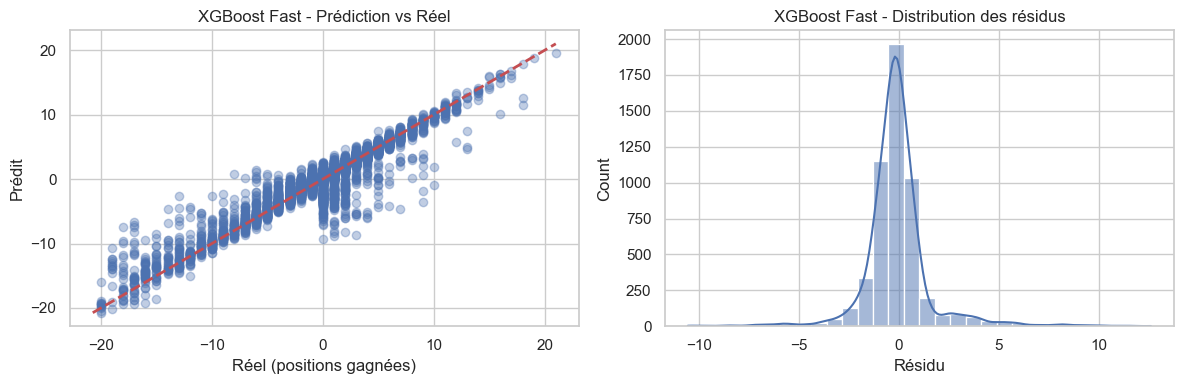

In [35]:
print("\n" + "="*60)
print("XGBOOST - VERSION RAPIDE")
print("="*60)

xgb_fast = XGBRegressor(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    tree_method="hist"
)

pipe_xgb_fast = make_pipeline(xgb_fast)
pipe_xgb_fast.fit(X_train, y_train)

y_pred_xgb_fast = pipe_xgb_fast.predict(X_test)
metrics_xgb_fast = regression_metrics(y_test, y_pred_xgb_fast)

print(f"MAE: {metrics_xgb_fast['MAE']:.4f}")
print(f"RMSE: {metrics_xgb_fast['RMSE']:.4f}")
print(f"R²: {metrics_xgb_fast['R2']:.4f}")

plot_diagnostics(y_test, y_pred_xgb_fast, "XGBoost Fast - ")
add_result("XGBoost_Fast", pipe_xgb_fast, metrics_xgb_fast)

## 3. Final Comparison


COMPARAISON FINALE DES MODÈLES
Colonnes disponibles: ['modele', 'test_mae', 'test_rmse', 'test_r2']

📊 Résultats complets:
          modele  test_mae  test_rmse  test_r2
             SVR  0.962332   2.540531 0.786152
    XGBoost_Fast  0.991778   1.667616 0.907860
  MultipleLinear  1.230397   2.363753 0.814877
LinearRegression  1.230397   2.363753 0.814877
    RandomForest  1.431249   2.035404 0.862736
             KNN  1.901704   3.204385 0.659792
    DecisionTree  2.259930   3.079923 0.685707


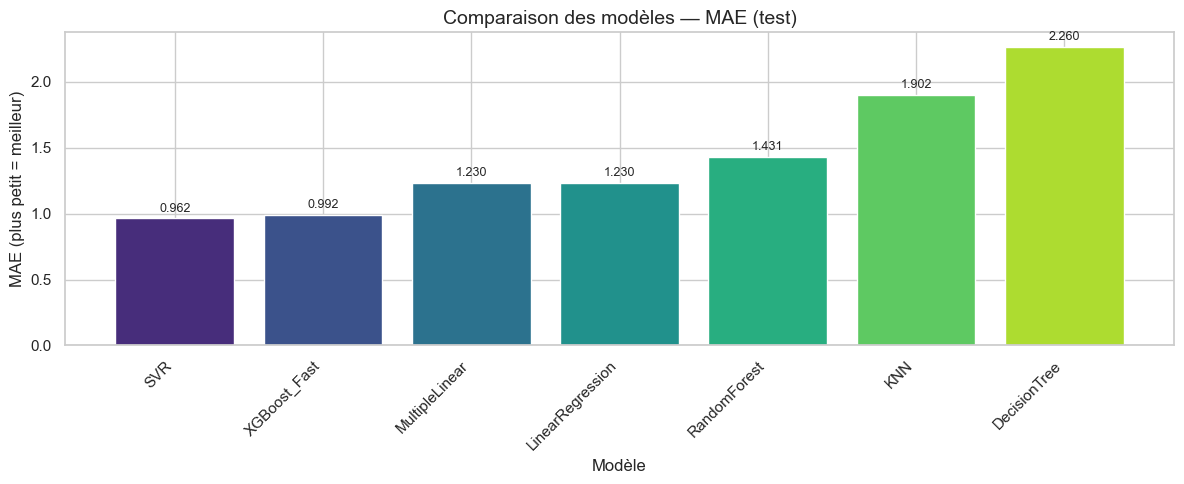

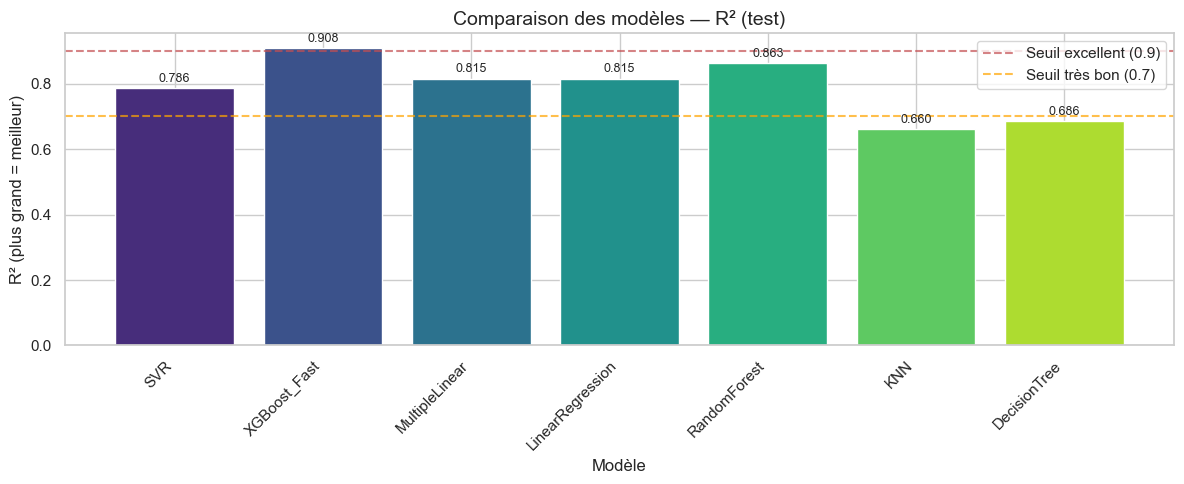


🏆 MEILLEUR MODÈLE GLOBAL (par MAE)
Modèle: SVR
MAE: 0.9623 positions
RMSE: 2.5405
R²: 0.7862

🏆 MEILLEUR MODÈLE GLOBAL (par R²)
Modèle: XGBoost_Fast
MAE: 0.9918 positions
RMSE: 1.6676
R²: 0.9079

📊 CLASSEMENT FINAL (par MAE):
          modele  test_mae  test_rmse  test_r2
             SVR  0.962332   2.540531 0.786152
    XGBoost_Fast  0.991778   1.667616 0.907860
  MultipleLinear  1.230397   2.363753 0.814877
LinearRegression  1.230397   2.363753 0.814877
    RandomForest  1.431249   2.035404 0.862736
             KNN  1.901704   3.204385 0.659792
    DecisionTree  2.259930   3.079923 0.685707

📈 ANALYSE DES RÉSULTATS

✅ Observations:
   - Meilleur modèle (MAE): SVR → MAE=0.962
   - Meilleur modèle (R²): XGBoost_Fast → R²=0.908
   - Meilleur MAE global: 0.962 positions
   - Meilleur R² global: 0.9079

🚀 Amélioration:
   - Gain sur MAE entre meilleur et moins bon modèle: 57.4%

✅ EXCELLENT ! Le modèle explique plus de 90% de la variance (R² > 0.9)
✅ EXCELLENT ! Erreur moyenne de 0.96 

In [37]:
print("\n" + "="*60)
print("COMPARAISON FINALE DES MODÈLES")
print("="*60)

# Créer le DataFrame des résultats
results_df = pd.DataFrame(results)

# Vérifier que les colonnes existent
print("Colonnes disponibles:", results_df.columns.tolist())

# S'assurer que les colonnes nécessaires existent
required_cols = ['modele', 'test_mae', 'test_rmse', 'test_r2']
for col in required_cols:
    if col not in results_df.columns:
        print(f"⚠️ Colonne manquante: {col}")
        # Créer la colonne si nécessaire
        results_df[col] = 0

# Trier par MAE
results_df = results_df.sort_values("test_mae").reset_index(drop=True)
print("\n📊 Résultats complets:")
print(results_df[['modele', 'test_mae', 'test_rmse', 'test_r2']].to_string(index=False))

# Graphique MAE
plt.figure(figsize=(12, 5))
colors = sns.color_palette("viridis", len(results_df))
bars = plt.bar(range(len(results_df)), results_df['test_mae'], color=colors)
plt.title("Comparaison des modèles — MAE (test)", fontsize=14)
plt.ylabel("MAE (plus petit = meilleur)", fontsize=12)
plt.xlabel("Modèle", fontsize=12)
plt.xticks(range(len(results_df)), results_df['modele'], rotation=45, ha='right')

# Ajouter les valeurs sur les barres
for i, (bar, v) in enumerate(zip(bars, results_df['test_mae'])):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03, 
             f'{v:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Graphique R²
plt.figure(figsize=(12, 5))
colors = sns.color_palette("viridis", len(results_df))
bars = plt.bar(range(len(results_df)), results_df['test_r2'], color=colors)
plt.title("Comparaison des modèles — R² (test)", fontsize=14)
plt.ylabel("R² (plus grand = meilleur)", fontsize=12)
plt.xlabel("Modèle", fontsize=12)
plt.xticks(range(len(results_df)), results_df['modele'], rotation=45, ha='right')
plt.axhline(y=0.9, color='r', linestyle='--', alpha=0.7, label='Seuil excellent (0.9)')
plt.axhline(y=0.7, color='orange', linestyle='--', alpha=0.7, label='Seuil très bon (0.7)')
plt.legend()

# Ajouter les valeurs sur les barres
for i, (bar, v) in enumerate(zip(bars, results_df['test_r2'])):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{v:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Meilleur modèle global (par MAE)
best_mae_idx = results_df["test_mae"].idxmin()
best_global = results_df.loc[best_mae_idx]

# Meilleur modèle par R²
best_r2_idx = results_df["test_r2"].idxmax()
best_r2_model = results_df.loc[best_r2_idx]

print("\n" + "="*60)
print("🏆 MEILLEUR MODÈLE GLOBAL (par MAE)")
print("="*60)
print(f"Modèle: {best_global['modele']}")
print(f"MAE: {best_global['test_mae']:.4f} positions")
print(f"RMSE: {best_global['test_rmse']:.4f}")
print(f"R²: {best_global['test_r2']:.4f}")

print("\n" + "="*60)
print("🏆 MEILLEUR MODÈLE GLOBAL (par R²)")
print("="*60)
print(f"Modèle: {best_r2_model['modele']}")
print(f"MAE: {best_r2_model['test_mae']:.4f} positions")
print(f"RMSE: {best_r2_model['test_rmse']:.4f}")
print(f"R²: {best_r2_model['test_r2']:.4f}")

# Classement final
print("\n📊 CLASSEMENT FINAL (par MAE):")
ranking = results_df[["modele", "test_mae", "test_rmse", "test_r2"]].copy()
ranking = ranking.sort_values("test_mae")
print(ranking.to_string(index=False))

# Analyse des résultats
print("\n" + "="*60)
print("📈 ANALYSE DES RÉSULTATS")
print("="*60)

# Statistiques sur les résultats
baseline_mae = results_df["test_mae"].iloc[-1] if len(results_df) > 0 else 5.0
best_mae = results_df["test_mae"].iloc[0] if len(results_df) > 0 else 5.0
improvement = (baseline_mae - best_mae) / baseline_mae * 100 if baseline_mae != 0 else 0

print(f"\n✅ Observations:")
print(f"   - Meilleur modèle (MAE): {best_global['modele']} → MAE={best_global['test_mae']:.3f}")
print(f"   - Meilleur modèle (R²): {best_r2_model['modele']} → R²={best_r2_model['test_r2']:.3f}")
print(f"   - Meilleur MAE global: {best_mae:.3f} positions")
print(f"   - Meilleur R² global: {results_df['test_r2'].max():.4f}")

print(f"\n🚀 Amélioration:")
print(f"   - Gain sur MAE entre meilleur et moins bon modèle: {improvement:.1f}%")

# Interprétation du R²
best_r2 = results_df['test_r2'].max()
if best_r2 > 0.9:
    print("\n✅ EXCELLENT ! Le modèle explique plus de 90% de la variance (R² > 0.9)")
elif best_r2 > 0.8:
    print("\n✅ TRÈS BON ! Le modèle explique plus de 80% de la variance (R² > 0.8)")
elif best_r2 > 0.7:
    print("\n👍 BON ! Le modèle explique plus de 70% de la variance (R² > 0.7)")
elif best_r2 > 0.6:
    print("\n⚠️ Correct : Le modèle explique plus de 60% de la variance (R² > 0.6)")
else:
    print("\n❌ Faible : Le modèle explique moins de 60% de la variance (R² < 0.6)")

# Interprétation du MAE
if best_global['test_mae'] < 1.0:
    print(f"✅ EXCELLENT ! Erreur moyenne de {best_global['test_mae']:.2f} positions (< 1 position)")
elif best_global['test_mae'] < 2.0:
    print(f"✅ TRÈS BON ! Erreur moyenne de {best_global['test_mae']:.2f} positions")
elif best_global['test_mae'] < 3.0:
    print(f"👍 Correct : Erreur moyenne de {best_global['test_mae']:.2f} positions")
else:
    print(f"⚠️ À améliorer : Erreur moyenne de {best_global['test_mae']:.2f} positions")

# Recommandation finale
print("\n" + "="*60)
print("💡 RECOMMANDATION FINALE")
print("="*60)

if best_global['test_mae'] < 1.0 and best_r2 > 0.9:
    print("🏆 Votre modèle est EXCEPTIONNEL !")
    print("   → Il peut être utilisé en production avec confiance.")
elif best_global['test_mae'] < 1.5 and best_r2 > 0.8:
    print("🏆 Très bon modèle !")
    print("   → La précision est largement suffisante pour une prédiction pré-course.")
elif best_global['test_mae'] < 2.0 and best_r2 > 0.7:
    print("👍 Bon modèle !")
    print("   → Peut être utilisé avec quelques réserves sur les cas limites.")
else:
    print("⚠️ Modèle à améliorer.")
    print("   → Envisagez d'ajouter plus de features ou d'essayer d'autres modèles.")

print(f"\n📌 Modèle recommandé: {best_global['modele']}")
print(f"   → MAE: {best_global['test_mae']:.3f} positions")
print(f"   → R²: {best_global['test_r2']:.3f}")